# 03 · Finding the threshold

**Goal:** sweep physical error rate `p` across several distances and find where the curves cross.

Below threshold, higher distance → lower logical error (redundancy wins). Above threshold, higher distance → higher logical error (too many error mechanisms to disambiguate). The crossing is the threshold.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))  # repo root
sys.path.insert(0, os.path.abspath('.'))
import numpy as np
import matplotlib.pyplot as plt
from surface_code import logical_error_rate

## Sweep
Rounds are set equal to distance (standard choice). 20k shots per point gives reasonable error bars; raise it to resolve very low rates.

In [2]:
distances = [3, 5, 7]
ps = np.linspace(0.002, 0.02, 8)

results = {}
for d in distances:
    results[d] = [logical_error_rate(d, d, float(p), shots=20000) for p in ps]
    print(f'd={d} done')

d=3 done


d=5 done


d=7 done


## Plot (Okabe-Ito colorblind-safe palette)

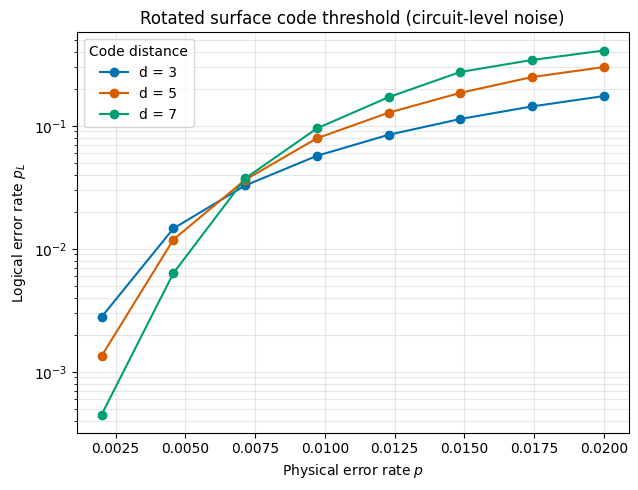

In [3]:
okabe_ito = ['#0072B2', '#D55E00', '#009E73', '#CC79A7']
fig, ax = plt.subplots(figsize=(6.5, 5))
for i, d in enumerate(distances):
    ax.plot(ps, results[d], 'o-', color=okabe_ito[i], label=f'd = {d}')
ax.set_yscale('log')
ax.set_xlabel('Physical error rate $p$')
ax.set_ylabel('Logical error rate $p_L$')
ax.set_title('Rotated surface code threshold (circuit-level noise)')
ax.legend(title='Code distance')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## Reading the result
The crossing sits near **p ≈ 0.6%**, consistent with the literature for circuit-level depolarizing noise. Note this is *lower* than the ~3% you see quoted for phenomenological noise — because here every gate and ancilla operation is noisy, not just data qubits and measurements. Always state which noise model a threshold refers to.